# Full - FinBERT Sentiment Analysis - BoE Speeches.ipynb [DM]

### FinBERT and LM Dictionary Sentiment Analysis:
##### *Bank of England speeches dataset*.

<div class="alert alert-block alert-info">
Notebook Start

#### Import and install libraries

In [2]:
# Install libraries
!pip install transformers pandas torch

from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import pandas as pd
import numpy as np


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


#### Load BoE Speeches

In [4]:
# Import the pre cleaned speeches data file
sp_df = pd.read_csv("uk_speeches.csv")


In [5]:
len(sp_df)

1190

In [6]:
# sp_samp = sp_df.loc[0:99]
# sp_samp

#### Pre-filter function for non-speech content
##### There are some speeches that had a large number of full stops (.), which were each being treated as tokens and causing problems when running the FinBERT model on the UK speeches dataset. For this reason we created the below function, which identifies speeches that have more than 10 full stops in a row (..........) and categorises rows using a boolean format as 'is_non_sppech'. These can then be filtered out of the sp_df dataset before running FinBERT sentiment analysis. 

In [8]:
import re

def is_non_speech(text):
    if not isinstance(text, str):
        return True

    # Check for patterns
    # has_glossary = bool(re.search(r'glossary|executive summary|table of contents', text, re.IGNORECASE))
    has_long_dots = bool(re.search(r'\.{10,}', text))
    # has_page_ref = bool(re.search(r'page\s+\d+', text, re.IGNORECASE))
    # has_url = bool(re.search(r'www\.\w+\.\w+', text))

    return (
        # text.count('.') > 100 or
        # len(text) < 100 or
        # has_glossary or
        has_long_dots
        # has_page_ref or
        # has_url
    )


#### Apply the is_non_speech function to the speeches dataframe

In [10]:
# Flag non-speech rows
sp_df['is_non_speech'] = sp_df['text'].apply(is_non_speech)

print(f"Filtered out {sp_df['is_non_speech'].sum()} non-speech rows.")

sp_df[sp_df['is_non_speech']]['text'].head()



Filtered out 10 non-speech rows.


91      This paper is an empirical analysis of unemplo...
213     Search for yield' and vulnerabilities ...........
332     It is with great pleasure I come to Cardiff Un...
899     Everyone can create money; the problem is to g...
1060    Introduction: the operational risk explosion ....
Name: text, dtype: object

In [11]:
sp_df[sp_df['is_non_speech'] == True]



,reference,country,date,title,author,text,is_non_speech
91,r010603a_BOE,united kingdom,03/06/2001,"The Beveridge Curve, Unemployment and Wages in...",nickell,This paper is an empirical analysis of unemplo...,True
213,r051128a_BOE,united kingdom,28/11/2005,Financial Stability: Managing Liquidity Risk i...,large,Search for yield' and vulnerabilities ...........,True
332,r090324a_BOE,united kingdom,24/03/2009,The Future of Monetary Policy,blanchflower,It is with great pleasure I come to Cardiff Un...,True
899,r180302a_BOE,united kingdom,02/03/2018,The Future of Money,carney,Everyone can create money; the problem is to g...,True
1060,r200909b_BOE,united kingdom,09/09/2020,The financial “plumbing” committee,stheeman,Introduction: the operational risk explosion ....,True
1065,r201006a_BOE,united kingdom,06/10/2020,Resilience in a time of uncertainty,strange,This publication is available on the BIS websi...,True
1072,r201026b_BOE,united kingdom,26/10/2020,"Response, and recovery: fintech during the Cov...",mutton,The Financial Stability Board (FSB) is establi...,True
1154,r220426a_BOE,united kingdom,26/04/2022,Bufferati,woods,Copies of publications are available from: Thi...,True
1158,r220519a_BOE,united kingdom,19/05/2022,Central clearing: three lessons and a path for...,knowles,This publication is available on the BIS websi...,True
1174,r220714a_BOE,united kingdom,14/07/2022,Capital and (for a change) Liquidity Buffers,saporta,This publication is available on the BIS websi...,True


In [12]:
# Filter non_speeches out
sp_df = sp_df[~sp_df['is_non_speech']].copy()
len(sp_df)

1180

#### Apply LM Dictionary Preprocessing

In [14]:
# Create LM dictionary
lm_dict = pd.read_csv("LM_dictionary.csv")
lm_dict

# Create a mapping: word → list of sentiment categories
lm_dict_map = {}
for _, row in lm_dict.iterrows():
    word = row['Word'].upper()
    categories = [col for col in lm_dict.columns[1:] if row[col] > 0]
    lm_dict_map[word] = categories

# Define LM Sentiment Scoring Function
import re

def lm_sentiment(text, lm_dict_map):
    words = re.findall(r'\b\w+\b', text.upper())
    pos = sum(1 for w in words if 'Positive' in lm_dict_map.get(w, []))
    neg = sum(1 for w in words if 'Negative' in lm_dict_map.get(w, []))
    total = pos + neg
    return 0 if total == 0 else (pos - neg) / total

# Apply it to BoE Speeches
sp_df['lm_score'] = sp_df['text'].apply(lambda x: lm_sentiment(x, lm_dict_map))
sp_df.head()

,reference,country,date,title,author,text,is_non_speech,lm_score
0,r980915a_BOE,united kingdom,15/09/1998,Speech,george,"Thank you, Chairman. I'm actually very pleased...",False,-0.235294
1,r981021b_BOE,united kingdom,21/10/1998,Britain in Europe,george,It's a great pleasure to be here in the beauti...,False,-0.029586
2,r981021a_BOE,united kingdom,21/10/1998,Impact of the recent turbulence in internation...,king,Few industries have suffered more from volatil...,False,-0.297872
3,r981101a_BOE,united kingdom,01/11/1998,"Economic policy, with and without forecasts",budd,My topic this evening is the use of forecasts ...,False,-0.289256
4,r981101b_BOE,united kingdom,01/11/1998,Inflation targeting in practice: the UK experi...,vickers,"Six years ago this week, sterling left the exc...",False,-0.378378


#### Combining with FinBERT model

In [18]:
# Imports
import nltk
import torch
import pandas as pd
from nltk.tokenize import sent_tokenize
from transformers import pipeline, AutoTokenizer
from collections import defaultdict

# Download sentence tokenizer
nltk.download('punkt')

# Step 1: Load FinBERT and tokenizer
device = 0 if torch.cuda.is_available() else -1
finbert = pipeline("sentiment-analysis", model="yiyanghkust/finbert-tone", device=device)
tokenizer = AutoTokenizer.from_pretrained("yiyanghkust/finbert-tone")

# Step 2: Extract and truncate sentences with logging
sentence_map = []
truncation_log = defaultdict(int)  # Tracks how many sentences were truncated per row

for idx, text in sp_df['text'].items():
    for sent in sent_tokenize(text):
        token_count = len(tokenizer.tokenize(sent))
        if token_count <= 512:
            sentence_map.append((idx, sent))
        else:
            # Truncate and log
            truncated = tokenizer.convert_tokens_to_string(tokenizer.tokenize(sent)[:512])
            sentence_map.append((idx, truncated))
            truncation_log[idx] += 1
            print(f"Truncated sentence ({token_count} → 512 tokens): {sent[:100]}...")

# Step 3: Run FinBERT in batches
sentences = [s[1] for s in sentence_map]
results = finbert(sentences)

# Step 4: Reconstruct per-row sentiment lists
row_sentiments = defaultdict(list)
for (idx, _), result in zip(sentence_map, results):
    row_sentiments[idx].append(result['label'])

# Step 5: Assign back to DataFrame
sp_df['finbert_sentences'] = sp_df.index.to_series().map(lambda i: row_sentiments[i])


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Medin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
Device set to use cpu


In [19]:
from collections import Counter

def summarize_sentiment(sent_list):
    counts = Counter(sent_list)
    total = sum(counts.values())
    return {
        'positive_pct': counts['Positive'] / total,
        'negative_pct': counts['Negative'] / total,
        'neutral_pct': counts['Neutral'] / total
    }

sp_df[['positive_pct', 'negative_pct', 'neutral_pct']] = sp_df['finbert_sentences'].apply(summarize_sentiment).apply(pd.Series)


In [20]:
sp_df

,reference,country,date,title,author,text,is_non_speech,lm_score,finbert_sentences,positive_pct,negative_pct,neutral_pct
0,r980915a_BOE,united kingdom,15/09/1998,Speech,george,"Thank you, Chairman. I'm actually very pleased...",False,-0.235294,"[Neutral, Positive, Negative, Neutral, Neutral...",0.180723,0.373494,0.445783
1,r981021b_BOE,united kingdom,21/10/1998,Britain in Europe,george,It's a great pleasure to be here in the beauti...,False,-0.029586,"[Neutral, Neutral, Positive, Neutral, Negative...",0.238806,0.305970,0.455224
2,r981021a_BOE,united kingdom,21/10/1998,Impact of the recent turbulence in internation...,king,Few industries have suffered more from volatil...,False,-0.297872,"[Negative, Neutral, Neutral, Negative, Negativ...",0.115789,0.463158,0.421053
3,r981101a_BOE,united kingdom,01/11/1998,"Economic policy, with and without forecasts",budd,My topic this evening is the use of forecasts ...,False,-0.289256,"[Neutral, Neutral, Neutral, Neutral, Neutral, ...",0.068966,0.078818,0.852217
4,r981101b_BOE,united kingdom,01/11/1998,Inflation targeting in practice: the UK experi...,vickers,"Six years ago this week, sterling left the exc...",False,-0.378378,"[Positive, Neutral, Neutral, Neutral, Neutral,...",0.066667,0.116667,0.816667
...,...,...,...,...,...,...,...,...,...,...,...,...
1185,r221007a_BOE,united kingdom,07/10/2022,"Shocks, inflation, and the policy response",ramsden,Thank you very much for the invitation to spea...,False,-0.364486,"[Neutral, Neutral, Neutral, Positive, Negative...",0.136364,0.266234,0.597403
1186,r221012a_BOE,united kingdom,12/10/2022,Monetary policy: an anchor in challenging times,pill,Huw Pill talks about how we will bring inflati...,False,-0.207547,"[Neutral, Neutral, Neutral, Neutral, Neutral, ...",0.115385,0.243590,0.641026
1187,r221015a_BOE,united kingdom,15/10/2022,Monetary policy and financial stability interv...,bailey,We are meeting in the most difficult of times....,False,-0.546667,"[Neutral, Neutral, Neutral, Neutral, Negative,...",0.079545,0.284091,0.636364
1188,r221019a_BOE,united kingdom,19/10/2022,"Governance of “Decentralised” Finance: Get up,...",wilkins,"These are divided into seven categories, suffr...",False,0.316129,"[Neutral, Neutral, Neutral, Neutral, Neutral, ...",0.064815,0.018519,0.916667


##### After running FinBERT sentiment analysis, we had a column with Positive/Negative/Neutral sentiment scores for each sentance within the speech text. We then calculated the number of each sentiment scores per speech and divided them by the total number of sentences per speech, obtaining a percentage of how many positive, negative and neutral sentences we have per speech.   

#### Calculate Single sentiment score from FinBERT.
##### We clalculated the overall FinBERT score per speech by adding the number of positive speeches (+1) and substracting negative speeches (-1) then dividing them by the total number of sentences to obtain a value between -1 and 1. Values closer to -1 represent a negative score, values closer to 0 represent a more neutral score, and values closer to 1 indicate a more positive score.

In [40]:
# Create labels map 
label_map = {
    'Positive': 1,
    'Neutral': 0,
    'Negative': -1
}

# Convert sentiment lists to scores
def compute_sentiment_score(label_list):
    scores = [label_map[label] for label in label_list]
    return sum(scores) / len(scores) if scores else 0

# Apply to the speeches dataframe
sp_df['finbert_score'] = sp_df['finbert_sentences'].apply(compute_sentiment_score)


In [42]:
sp_df

,reference,country,date,title,author,text,is_non_speech,lm_score,finbert_sentences,positive_pct,negative_pct,neutral_pct,finbert_score
0,r980915a_BOE,united kingdom,15/09/1998,Speech,george,"Thank you, Chairman. I'm actually very pleased...",False,-0.235294,"[Neutral, Positive, Negative, Neutral, Neutral...",0.180723,0.373494,0.445783,-0.192771
1,r981021b_BOE,united kingdom,21/10/1998,Britain in Europe,george,It's a great pleasure to be here in the beauti...,False,-0.029586,"[Neutral, Neutral, Positive, Neutral, Negative...",0.238806,0.305970,0.455224,-0.067164
2,r981021a_BOE,united kingdom,21/10/1998,Impact of the recent turbulence in internation...,king,Few industries have suffered more from volatil...,False,-0.297872,"[Negative, Neutral, Neutral, Negative, Negativ...",0.115789,0.463158,0.421053,-0.347368
3,r981101a_BOE,united kingdom,01/11/1998,"Economic policy, with and without forecasts",budd,My topic this evening is the use of forecasts ...,False,-0.289256,"[Neutral, Neutral, Neutral, Neutral, Neutral, ...",0.068966,0.078818,0.852217,-0.009852
4,r981101b_BOE,united kingdom,01/11/1998,Inflation targeting in practice: the UK experi...,vickers,"Six years ago this week, sterling left the exc...",False,-0.378378,"[Positive, Neutral, Neutral, Neutral, Neutral,...",0.066667,0.116667,0.816667,-0.050000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1185,r221007a_BOE,united kingdom,07/10/2022,"Shocks, inflation, and the policy response",ramsden,Thank you very much for the invitation to spea...,False,-0.364486,"[Neutral, Neutral, Neutral, Positive, Negative...",0.136364,0.266234,0.597403,-0.129870
1186,r221012a_BOE,united kingdom,12/10/2022,Monetary policy: an anchor in challenging times,pill,Huw Pill talks about how we will bring inflati...,False,-0.207547,"[Neutral, Neutral, Neutral, Neutral, Neutral, ...",0.115385,0.243590,0.641026,-0.128205
1187,r221015a_BOE,united kingdom,15/10/2022,Monetary policy and financial stability interv...,bailey,We are meeting in the most difficult of times....,False,-0.546667,"[Neutral, Neutral, Neutral, Neutral, Negative,...",0.079545,0.284091,0.636364,-0.204545
1188,r221019a_BOE,united kingdom,19/10/2022,"Governance of “Decentralised” Finance: Get up,...",wilkins,"These are divided into seven categories, suffr...",False,0.316129,"[Neutral, Neutral, Neutral, Neutral, Neutral, ...",0.064815,0.018519,0.916667,0.046296


In [21]:
# # Export CSV
sp_df.to_csv("Full_FinBERT_speeches.csv", encoding='utf-8')

In [46]:
sp_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1180 entries, 0 to 1189
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   reference          1180 non-null   object 
 1   country            1180 non-null   object 
 2   date               1180 non-null   object 
 3   title              1180 non-null   object 
 4   author             1180 non-null   object 
 5   text               1180 non-null   object 
 6   is_non_speech      1180 non-null   bool   
 7   lm_score           1180 non-null   float64
 8   finbert_sentences  1180 non-null   object 
 9   positive_pct       1180 non-null   float64
 10  negative_pct       1180 non-null   float64
 11  neutral_pct        1180 non-null   float64
 12  finbert_score      1180 non-null   float64
dtypes: bool(1), float64(5), object(7)
memory usage: 121.0+ KB


#### Aggregate and group by yearly averegae for FinBERT and LM sentiment scores.

In [55]:
# Step 1: Convert 'date' to datetime format
sp_df['date'] = pd.to_datetime(sp_df['date'], dayfirst=True, errors='coerce')

# Step 2: Extract year
sp_df['year'] = sp_df['date'].dt.year

# Step 3: Group by year and calculate average sentiment
sp_year_avg = sp_df.groupby('year', as_index=False)[
    ['finbert_score', 'lm_score']].mean()


sp_year_avg

,year,finbert_score,lm_score
0,1998,-0.133274,-0.276035
1,1999,-0.062888,-0.110729
2,2000,0.002512,0.044273
3,2001,-0.115966,-0.148636
4,2002,-0.035279,-0.064322
5,2003,-0.043915,-0.099130
6,2004,-0.053962,-0.101267
7,2005,-0.104540,-0.102452
8,2006,-0.092488,-0.122338
9,2007,-0.058153,-0.128628


#### FinBERT vs LM - Group by and aggregate - Monthly average

In [79]:
# Step 1: Extract year and month
sp_df['year_month'] = sp_df['date'].dt.to_period('M')

# Step 2: Group by month and calculate average sentiment
sp_month_avg = sp_df.groupby('year_month', as_index=False)[
    ['finbert_score', 'lm_score']].mean()


sp_month_avg

,year_month,finbert_score,lm_score
0,1998-09,-0.192771,-0.235294
1,1998-10,-0.207266,-0.163729
2,1998-11,-0.090873,-0.315137
3,1998-12,-0.093135,-0.350057
4,1999-01,-0.289703,-0.282622
...,...,...,...
266,2022-05,-0.117739,-0.299927
267,2022-06,-0.048887,-0.189690
268,2022-07,-0.075165,-0.172142
269,2022-09,-0.084163,-0.329933


In [83]:
# Export monthly average sentiment score 
sp_month_avg.to_csv("Monthly_Sentiment_Score.csv", encoding='utf-8', index=False)

#### Plot FinBERT sentiment score (Yearly average)

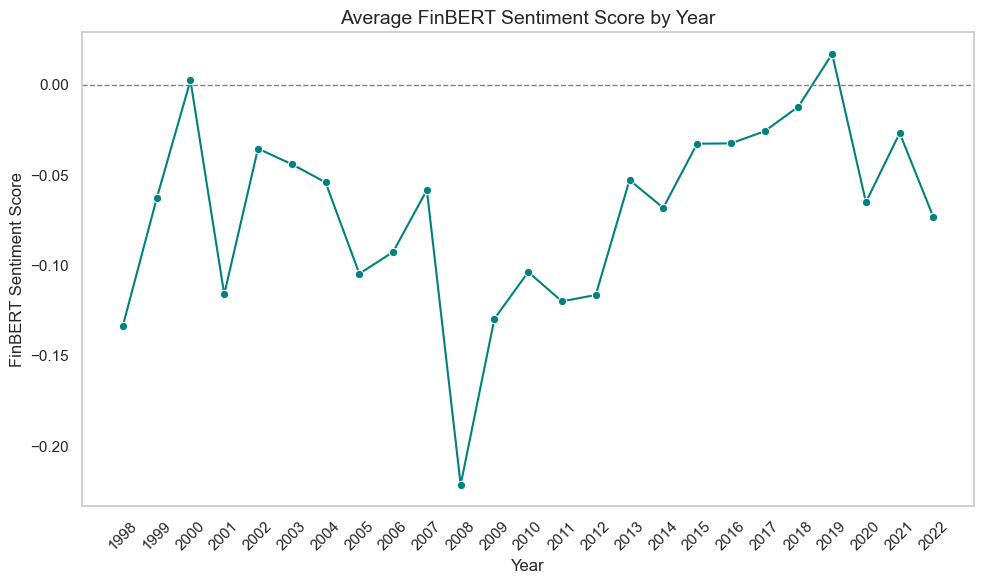

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure data is sorted
sp_year_avg = sp_year_avg.sort_values('year')

# Get full year range (even if some years are missing in data)
all_years = list(range(sp_year_avg['year'].min(), sp_year_avg['year'].max() + 1))

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=sp_year_avg, x='year', y='finbert_score', marker='o', color='teal')

# Customize x-axis to show all years
plt.xticks(all_years, rotation=45)
plt.xlabel('Year', fontsize=12)
plt.ylabel('FinBERT Sentiment Score', fontsize=12)
plt.title('Average FinBERT Sentiment Score by Year', fontsize=14)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.grid(False)
plt.tight_layout()
plt.show()


#### Dual-Axis Line Chart: LM Score vs FinBERT Score - Yearly Average 

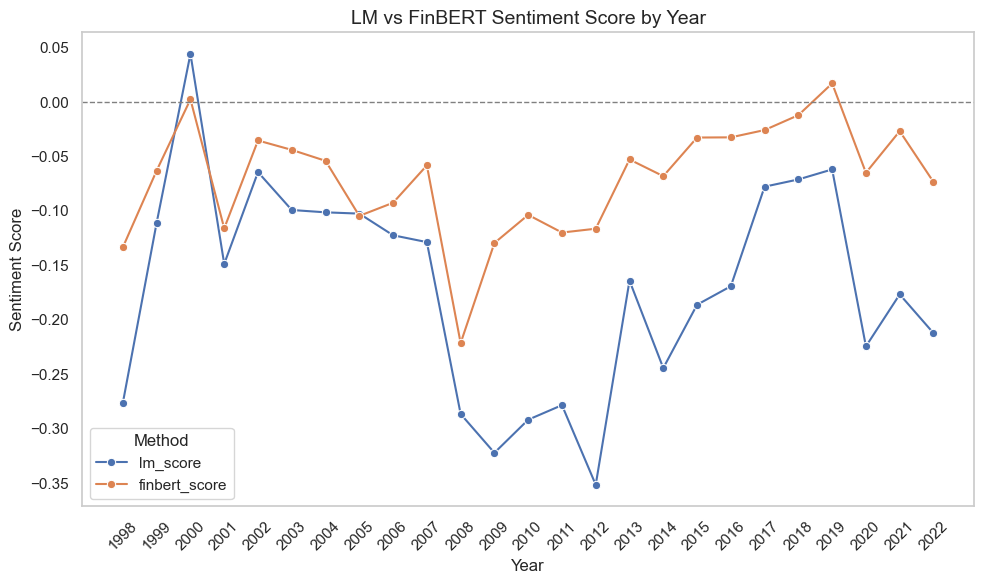

In [71]:
# Melt the DataFrame to long format for Seaborn
fin_lm = sp_year_avg.melt(id_vars='year', value_vars=['lm_score', 'finbert_score'],
                             var_name='method', value_name='sentiment_score')

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=fin_lm, x='year', y='sentiment_score', hue='method', marker='o')

# Customize
plt.title('LM vs FinBERT Sentiment Score by Year', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Sentiment Score', fontsize=12)
plt.xticks(fin_lm['year'].unique(), rotation=45)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.grid(False)
plt.tight_layout()
plt.legend(title='Method')
plt.savefig('FinBERT-vs-LM.png', dpi=300, bbox_inches='tight')


plt.show()


##### Both LM & FinBERT models show similar trends in sentiment for BoE. The LM model showed higher volatility due to its sensitivity to negative words. FinBERT smooths volatility by taking into account context-aware nuances.

<div class="alert alert-block alert-info">
Notebook End